## Problem Statement Clarity with Real-World Relevance

**Problem:** In the rapidly evolving movie industry, understanding the factors that drive a movie's popularity and user satisfaction is crucial for various stakeholders, including production studios, distributors, and streaming platforms. Given a dataset containing movie information, including ratings, votes, genres, and popularity metrics, the challenge is to analyze and model these attributes to gain insights into what makes a movie successful.

**Real-World Relevance:**

*   **For Production Studios:** By identifying key characteristics that contribute to high ratings and popularity, studios can make more informed decisions during movie development, from script selection to casting and production style. This can lead to increased box office success and critical acclaim.
*   **For Distributors and Marketers:** Understanding which genres, themes, or historical periods resonate most with audiences can help in tailoring marketing campaigns and distribution strategies to maximize reach and engagement.
*   **For Streaming Platforms:** Personalized recommendations are a cornerstone of modern streaming services. By building models that predict user ratings or popularity, platforms can improve their recommendation algorithms, leading to higher user satisfaction, increased viewing times, and reduced churn.
*   **For Viewers:** Ultimately, a better understanding of movie success factors can lead to the production of higher-quality content that aligns more closely with audience preferences, enriching the movie-watching experience for everyone.

**DATA UNDERSTANDING AND EXPLORATION**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor



In [2]:
df=pd.read_csv('/content/final_df (1).csv')
df.head()

,title,title_clean,year,genres,countries_origin,description,rating,votes,popularity,user_rating,tfidf_soup
0,The Dark Knight,the dark knight,2008,"Action Epic, Epic, Superhero, Tragedy, Action,...","United States, United Kingdom",When a menace known as the Joker wreaks havoc ...,9.0,3000000.0,1.000000,NaN,action epic epic superhero tragedy action ...
1,Inception,inception,2010,"Action Epic, Adventure Epic, Epic, Psychologic...","United States, United Kingdom",A thief who steals corporate secrets through t...,8.8,2700000.0,0.969451,4.066434,action epic adventure epic epic psychologic...
2,Interstellar,interstellar,2014,"Adventure Epic, Epic, Quest, Sci-Fi Epic, Spac...","United States, United Kingdom, Canada",When Earth becomes uninhabitable in the future...,8.7,2300000.0,0.946982,3.993151,adventure epic epic quest sci-fi epic spac...
3,The Lord of the Rings: The Return of the King,the lord of the rings the return of the king,2003,"Action Epic, Adventure Epic, Epic, Fantasy Epi...","New Zealand, United States",Gandalf and Aragorn lead the World of Men agai...,9.0,2100000.0,0.974920,NaN,action epic adventure epic epic fantasy epi...
4,The Lord of the Rings: The Fellowship of the Ring,the lord of the rings the fellowship of the ring,2001,"Action Epic, Adventure Epic, Dark Fantasy, Epi...","New Zealand, United States, United Kingdom",A meek Hobbit from the Shire and eight compani...,8.9,2100000.0,0.963546,NaN,action epic adventure epic dark fantasy epi...


In [3]:
df.shape

(15768, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15768 entries, 0 to 15767
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             15768 non-null  object 
 1   title_clean       15768 non-null  object 
 2   year              15768 non-null  int64  
 3   genres            15768 non-null  object 
 4   countries_origin  15768 non-null  object 
 5   description       15722 non-null  object 
 6   rating            15768 non-null  float64
 7   votes             15768 non-null  float64
 8   popularity        15768 non-null  float64
 9   user_rating       2959 non-null   float64
 10  tfidf_soup        15768 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 1.3+ MB


In [5]:
df.describe()

,year,rating,votes,popularity,user_rating
count,15768.000000,15768.000000,1.576800e+04,15768.000000,2959.000000
mean,2012.587773,6.326706,4.728894e+04,0.380260,3.187415
std,7.444935,1.087978,1.306379e+05,0.147010,0.803684
min,2000.000000,1.100000,5.000000e+00,0.000000,0.500000
25%,2006.000000,5.700000,1.100000e+03,0.274066,2.750000
50%,2013.000000,6.500000,5.700000e+03,0.371316,3.312500
75%,2019.000000,7.100000,3.200000e+04,0.476364,3.750000
max,2025.000000,10.000000,3.000000e+06,1.000000,5.000000


**Initial observations**

In [6]:
missing_values=df.isna()
missing_values

,title,title_clean,year,genres,countries_origin,description,rating,votes,popularity,user_rating,tfidf_soup
0,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
15763,False,False,False,False,False,False,False,False,False,True,False
15764,False,False,False,False,False,False,False,False,False,True,False
15765,False,False,False,False,False,False,False,False,False,True,False
15766,False,False,False,False,False,False,False,False,False,True,False


In [7]:
df.isna().sum()

,0
title,0
title_clean,0
year,0
genres,0
countries_origin,0
description,46
rating,0
votes,0
popularity,0
user_rating,12809


In [8]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df


,title,title_clean,year,genres,countries_origin,description,rating,votes,popularity,user_rating,tfidf_soup
0,The Dark Knight,the dark knight,2008,"Action Epic, Epic, Superhero, Tragedy, Action,...","United States, United Kingdom",When a menace known as the Joker wreaks havoc ...,9.0,3000000.0,1.000000,NaN,action epic epic superhero tragedy action ...
1,Inception,inception,2010,"Action Epic, Adventure Epic, Epic, Psychologic...","United States, United Kingdom",A thief who steals corporate secrets through t...,8.8,2700000.0,0.969451,4.066434,action epic adventure epic epic psychologic...
2,Interstellar,interstellar,2014,"Adventure Epic, Epic, Quest, Sci-Fi Epic, Spac...","United States, United Kingdom, Canada",When Earth becomes uninhabitable in the future...,8.7,2300000.0,0.946982,3.993151,adventure epic epic quest sci-fi epic spac...
3,The Lord of the Rings: The Return of the King,the lord of the rings the return of the king,2003,"Action Epic, Adventure Epic, Epic, Fantasy Epi...","New Zealand, United States",Gandalf and Aragorn lead the World of Men agai...,9.0,2100000.0,0.974920,NaN,action epic adventure epic epic fantasy epi...
4,The Lord of the Rings: The Fellowship of the Ring,the lord of the rings the fellowship of the ring,2001,"Action Epic, Adventure Epic, Dark Fantasy, Epi...","New Zealand, United States, United Kingdom",A meek Hobbit from the Shire and eight compani...,8.9,2100000.0,0.963546,NaN,action epic adventure epic dark fantasy epi...
...,...,...,...,...,...,...,...,...,...,...,...
15763,Revenge of the Boogeyman,revenge of the boogeyman,2025,Horror,United States,A group of friends take their recently sober f...,7.0,8.0,0.071458,NaN,horror horror a group of friends take their re...
15764,Canasta uruguaya,canasta uruguaya,2017,"Comedy, Drama",Mexico,Pablo pierde toda su fortuna contra Atenógenes...,5.0,8.0,0.037124,NaN,comedy drama comedy drama pablo pierde toda ...
15765,CatVideoFest,catvideofest,2019,Documentary,Unknown,A fest of the internet's favorite create: the ...,5.2,7.0,0.035772,NaN,documentary documentary a fest of the internet...
15766,"Langrishe, Go Down",langrishe go down,2002,Drama,United Kingdom,"In 1930s Ireland, three reclusive sisters inha...",8.1,7.0,0.082887,NaN,"drama drama in 1930s ireland, three reclusive ..."


In [9]:
df.shape

(15768, 11)

In [10]:
cat=df.select_dtypes(exclude=['number']).columns
num=df.select_dtypes(include=['number']).columns

In [11]:
num

Index(['year', 'rating', 'votes', 'popularity', 'user_rating'], dtype='object')

In [12]:
cat

Index(['title', 'title_clean', 'genres', 'countries_origin', 'description',
       'tfidf_soup'],
      dtype='object')

** Handling Missing Values**

Based on the `df.isna().sum()` output, we have missing values in 'description' and 'user_rating'.

*   **`description`**: There are 46 missing values. Since this is a text field, we'll fill these with an empty string to ensure text processing functions don't encounter `NaN` values.
*   **`user_rating`**: There are 12809 missing values, which is a significant portion. For numerical data, `KNNImputer` is a suitable method as it estimates missing values based on the average of its `k` nearest neighbors, which can preserve more of the underlying data distribution than simple mean/median imputation. It is more robust when dealing with a larger number of missing values.

In [13]:
# Fill missing 'description' values with an empty string
df['description'] = df['description'].fillna('')

# Impute missing 'user_rating' values using SimpleImputer with 'mean' strategy
mean_imputer = SimpleImputer(strategy='mean')
df['user_rating'] = mean_imputer.fit_transform(df[['user_rating']])

# Verify that there are no more missing values in these columns
df.isna().sum()

,0
title,0
title_clean,0
year,0
genres,0
countries_origin,0
description,0
rating,0
votes,0
popularity,0
user_rating,0


### Data Type Correction and Inconsistent Values

*   **`genres` and `countries_origin`**: These columns currently store lists as strings. I will convert them into actual Python lists to facilitate easier manipulation and analysis of individual genres and countries.
*   **`year`**: I will check the range of the 'year' column to identify any potential outliers or incorrect entries that might fall outside a reasonable range for movie release years.

In [14]:
# Optimize 'year' column type using .astype
# Given the year range (2000-2025), int16 is sufficient and more memory-efficient than int64
df['year'] = df['year'].astype('int16')

print(f"'year' column new dtype:", df['year'])

'year' column new dtype: 0        2008
1        2010
2        2014
3        2003
4        2001
         ... 
15763    2025
15764    2017
15765    2019
15766    2002
15767    2025
Name: year, Length: 15768, dtype: int16


 **Label Encoding for Text-based Categorical Features**

Following the request to apply label encoding to object-type columns, we will encode `title`, `title_clean`, `description`, and `tfidf_soup`. This converts their string values into numerical representations. It's important to note that for text-heavy columns like `description` and `tfidf_soup`, simple label encoding assigns arbitrary numerical values, which might not capture semantic relationships. For more advanced text analysis, techniques like TF-IDF or word embeddings are typically used. However, this step demonstrates the requested label encoding application.

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

dflabel = df.copy()

# Identify object columns for label encoding
object_cols = dflabel.select_dtypes(include='object').columns

# Apply LabelEncoder to each object column
le = LabelEncoder()
for col in object_cols:
    dflabel[col] = le.fit_transform(dflabel[col])

print("DataFrame after applying LabelEncoder to object columns:")
display(dflabel.head())

# Prepare features (X) and target (y) for the model
# We will use 'rating' as the target variable, consistent with previous modeling efforts
X_label = dflabel.drop(columns=['rating'], errors='ignore')
y_label = dflabel['rating']

# Split the data into training and testing sets
X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
# Using RandomForestRegressor as 'rating' is a continuous variable, not a classification target.
rf_model_label = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_label.fit(X_train_label, y_train_label)

# Make predictions on the test set
y_pred_label = rf_model_label.predict(X_test_label)

# Evaluate the model using regression metrics
mae_label = mean_absolute_error(y_test_label, y_pred_label)
rmse_label = np.sqrt(mean_squared_error(y_test_label, y_pred_label))

print(f"\nMean Absolute Error (MAE) with LabelEncoder: {mae_label:.4f}")
print(f"Root Mean Squared Error (RMSE) with LabelEncoder: {rmse_label:.4f}")

DataFrame after applying LabelEncoder to object columns:


,title,title_clean,year,genres,countries_origin,description,rating,votes,popularity,user_rating,tfidf_soup
0,11823,11817,2008,98,2309,15068,9.0,3000000.0,1.000000,3.187415,1091
1,5795,5782,2010,33,2309,4165,8.8,2700000.0,0.969451,4.066434,1022
2,5879,5868,2014,518,2317,14871,8.7,2300000.0,0.946982,3.993151,1557
3,12735,12730,2003,29,1183,8863,9.0,2100000.0,0.974920,3.187415,1017
4,12734,12729,2001,18,1184,2854,8.9,2100000.0,0.963546,3.187415,1005



Mean Absolute Error (MAE) with LabelEncoder: 0.0221
Root Mean Squared Error (RMSE) with LabelEncoder: 0.0727


### Scaling / Normalization

Scaling is an important preprocessing step, especially for algorithms that are sensitive to the magnitude and scale of input features (e.g., K-Nearest Neighbors, Support Vector Machines, neural networks, or algorithms using gradient descent). Two common methods are standardization and normalization.

*   **Standardization (Z-score normalization)**: Transforms data to have a mean of 0 and a standard deviation of 1. It is suitable when the data follows a Gaussian distribution or when the algorithm assumes zero-mean, unit-variance data. It's less affected by outliers than Min-Max scaling.
*   **Normalization (Min-Max scaling)**: Scales data to a fixed range, usually 0 to 1. This is useful when you need to maintain feature relationships but ensure all features have the same scale, or when algorithms require input values within a specific range.

For this dataset, we will use **Standardization** (`StandardScaler`) as it is a robust choice that works well with a wide range of algorithms and is less sensitive to outliers compared to Min-Max scaling. We will apply it to numerical columns like `year`, `votes`, `popularity`, and `user_rating`.

In [16]:
from sklearn.preprocessing import StandardScaler
numerical_cols_to_scale = ['year', 'votes', 'popularity', 'user_rating']
# Initialize the StandardScaler
scaler = StandardScaler()
# Apply StandardScaler to the selected numerical columns in the 'df' DataFrame
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("DataFrame after standardizing numerical features:")
display(df.head())
print(f"New shape: {df.shape}")

DataFrame after standardizing numerical features:


,title,title_clean,year,genres,countries_origin,description,rating,votes,popularity,user_rating,tfidf_soup
0,The Dark Knight,the dark knight,-0.616247,"Action Epic, Epic, Superhero, Tragedy, Action,...","United States, United Kingdom",When a menace known as the Joker wreaks havoc ...,9.0,22.602967,4.215753,0.000000,action epic epic superhero tragedy action ...
1,Inception,inception,-0.347599,"Action Epic, Adventure Epic, Epic, Psychologic...","United States, United Kingdom",A thief who steals corporate secrets through t...,8.8,20.306471,4.007948,2.525236,action epic adventure epic epic psychologic...
2,Interstellar,interstellar,0.189696,"Adventure Epic, Epic, Quest, Sci-Fi Epic, Spac...","United States, United Kingdom, Canada",When Earth becomes uninhabitable in the future...,8.7,17.244476,3.855104,2.314710,adventure epic epic quest sci-fi epic spac...
3,The Lord of the Rings: The Return of the King,the lord of the rings the return of the king,-1.287866,"Action Epic, Adventure Epic, Epic, Fantasy Epi...","New Zealand, United States",Gandalf and Aragorn lead the World of Men agai...,9.0,15.713478,4.045147,0.000000,action epic adventure epic epic fantasy epi...
4,The Lord of the Rings: The Fellowship of the Ring,the lord of the rings the fellowship of the ring,-1.556513,"Action Epic, Adventure Epic, Dark Fantasy, Epi...","New Zealand, United States, United Kingdom",A meek Hobbit from the Shire and eight compani...,8.9,15.713478,3.967778,0.000000,action epic adventure epic dark fantasy epi...


New shape: (15768, 11)


##**# Univariate Analysis: Understanding Individual Variables**

Univariate analysis is the simplest form of statistical analysis, where we analyze one variable at a time. Its primary goal is to describe the distribution of a single variable, understand its central tendency, spread, and shape, and identify any outliers or unusual patterns.




In [ ]:
def analyzecol(col):
  print("\n====================================")
  print("analysis of:",col)
  print("====================================\n")
  print("summary statistics")
  print(df[col].describe())

  print("\nkey measures")
  print("mean",df[col].mean())
  print("standard devaiation",df[col].std())
  print("skewness",df[col].skew())

  plt.figure()
  plt.hist(df[col].dropna(),bins=20)
  plt.title("histogram of"+col)
  plt.xlabel(col)
  plt.ylabel("frequency")
  plt.show()


  plt.figure()
  plt.boxplot(df[col].dropna())
  plt.title("boxplot of"+col)
  plt.show()


enter any columnrating

analysis of: rating

summary statistics
count    15768.000000
mean         6.326706
std          1.087978
min          1.100000
25%          5.700000
50%          6.500000
75%          7.100000
max         10.000000
Name: rating, dtype: float64

key measures
mean 6.326705986808727
standard devaiation 1.087977628403173
skewness -0.744333715086098


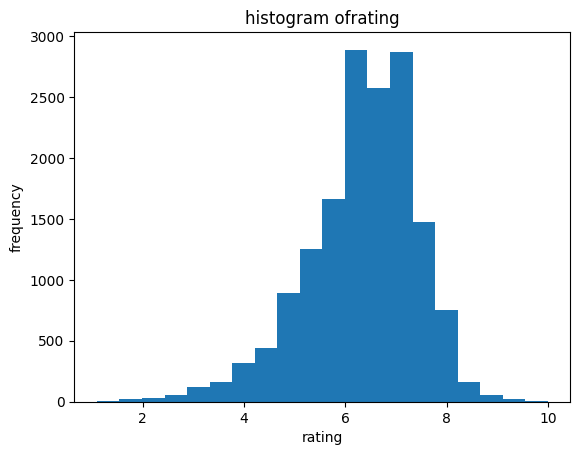

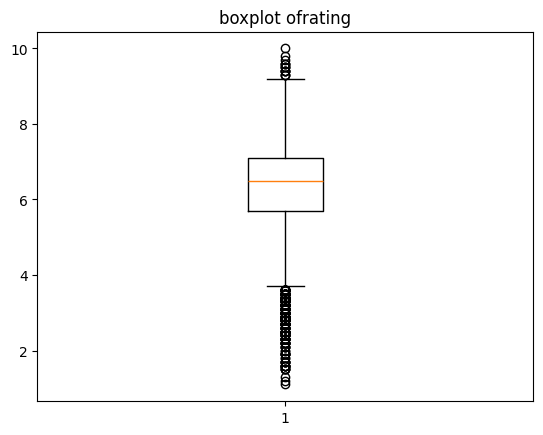

In [18]:
col=input("enter any column")
analyzecol(col)

**BIVARIATED ANALYSIS**

In [19]:
col1=input("enter 1st column").strip()
col2=input("enter 2nd column").strip()
bivariated=df[[col1,col2]]
bivariated.head()

enter 1st columnrating
enter 2nd columnvotes


,rating,votes
0,9.0,22.602967
1,8.8,20.306471
2,8.7,17.244476
3,9.0,15.713478
4,8.9,15.713478


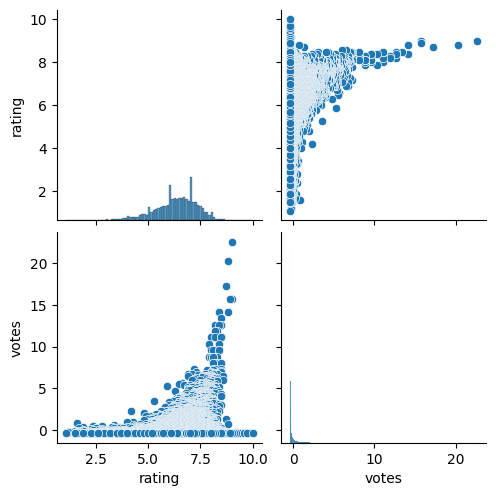

In [20]:
sns.pairplot(bivariated)

<Axes: >

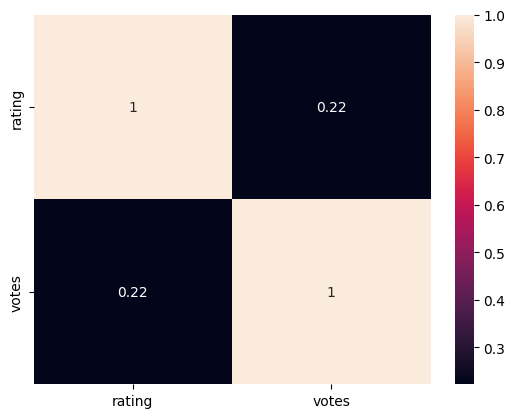

In [21]:
sns.heatmap(bivariated.corr("pearson"),annot=True)

**MULTIVARIATE ANALYSIS**



To understand the relationships between all numerical variables in the dataset, including the label-encoded genres and countries, we will compute and visualize their correlation matrix using a heatmap. This helps identify strong positive or negative correlations, which can be useful for feature selection or understanding underlying data patterns.

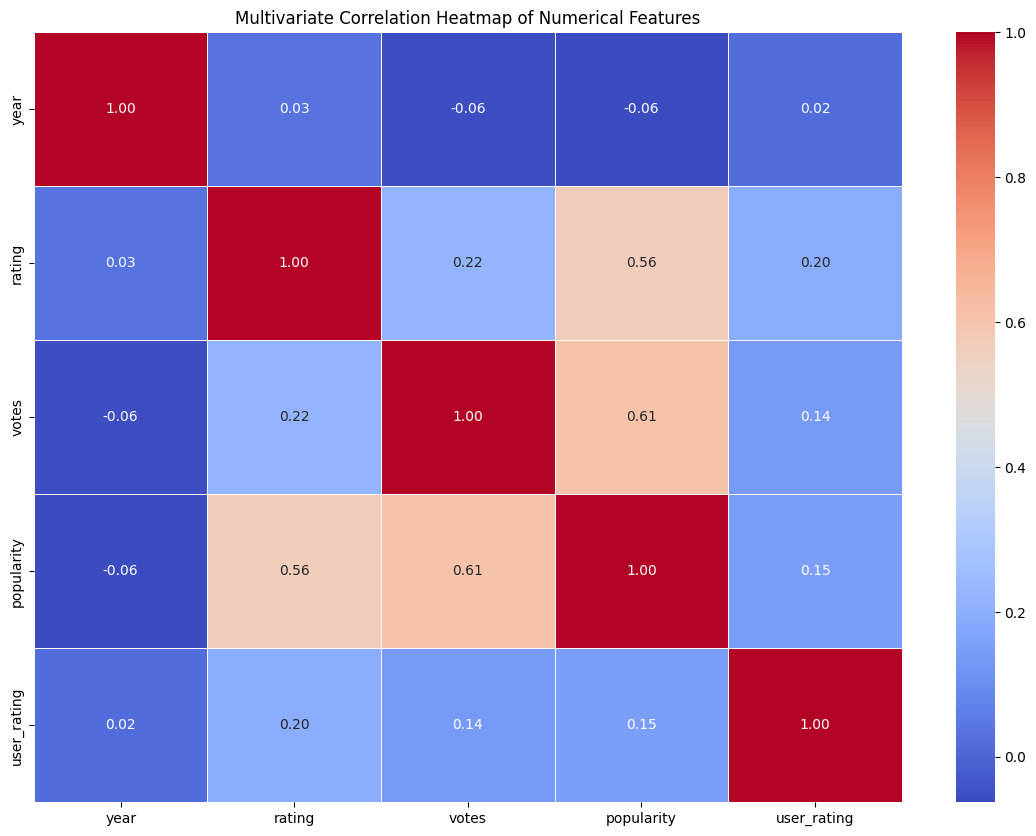

In [22]:
# Select all numerical columns for multivariate analysis
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Multivariate Correlation Heatmap of Numerical Features')
plt.show()

In [24]:
print(f"Total samples: {len(df)}")
print(f"Train samples: {len(y_train_label)}")
print(f"Test samples: {len(y_test_label)}\n")

Total samples: 15768
Train samples: 12614
Test samples: 3154



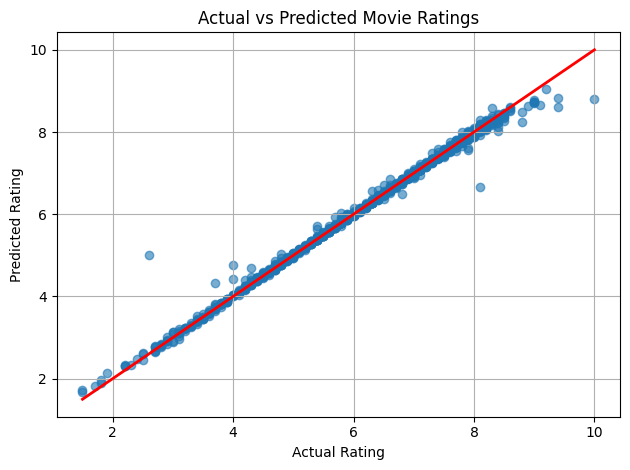

In [26]:
plt.figure()
plt.scatter(y_test_label, y_pred_label, alpha=0.6)
plt.plot([y_test_label.min(), y_test_label.max()],
         [y_test_label.min(), y_test_label.max()],
         color='red', lw=2)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
country_genre = df.groupby(['countries_origin', 'genres'])['popularity'].mean().reset_index()

top_genre = country_genre.sort_values('popularity', ascending=False).drop_duplicates('countries_origin')

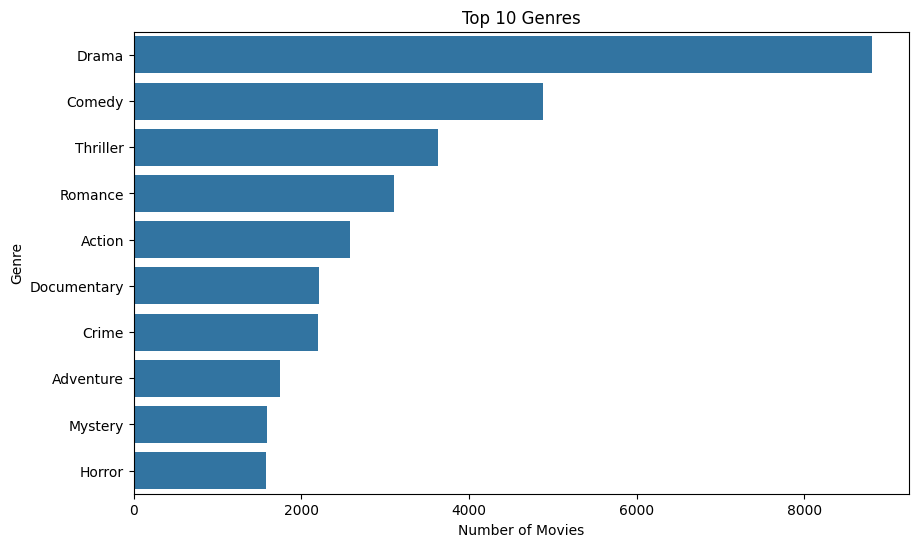

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Split the 'genres' column and count the occurrences of each genre
genre_counts = df['genres'].str.get_dummies(sep=', ').sum().sort_values(ascending=False)

# Select the top 10 genres
genre_counts = genre_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)

plt.title("Top 10 Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

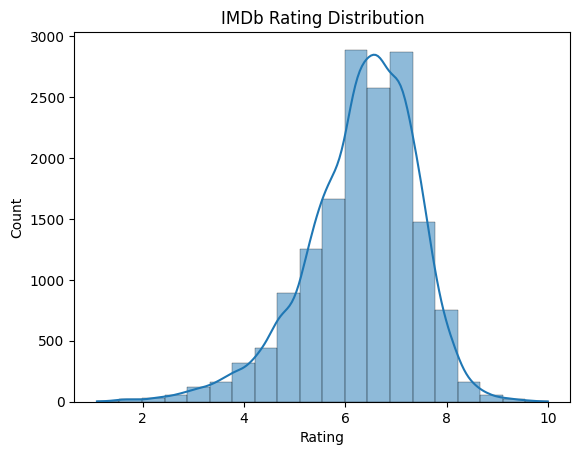

In [29]:
sns.histplot(df['rating'], bins=20, linewidth=0.2,kde=True)

plt.title("IMDb Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [30]:
import plotly.express as px

# Split 'countries_origin' into individual countries and explode to new rows
df_countries = df.assign(countries_origin=df['countries_origin'].str.split(', ')).explode('countries_origin')

# Calculate mean popularity for each country
country_popularity = df_countries.groupby('countries_origin')['popularity'].mean().reset_index()
country_popularity.rename(columns={'countries_origin': 'country'}, inplace=True)

fig = px.choropleth(
    country_popularity,
    locations='country',
    locationmode='country names',
    color='popularity',
    color_continuous_scale='Viridis',
    title=' Popular Content by Country'
)

fig.show()